# Teil 1 - Use Case Analyse

## 1. Datensatz-Beschreibung

Der Datensatz stammt laut [Kaggle](https://www.kaggle.com/datasets/prachi13/customer-analytics) aus einem E-Commerce-Kontext und enthält 10'999 Bestellungen mit 12 Spalten.

Erfasst werden:

- Logistik: `Warehouse_block`, `Mode_of_Shipment`, `Weight_in_gms`
- Kunde und Bestellung: `Customer_care_calls`, `Customer_rating`, `Gender`, `Prior_purchases`, `Cost_of_the_Product`, `Product_importance`, `Discount_offered`
- Zielvariable: `Reached.on.Time_Y.N`, mit 0 = pünktlich und 1 = verspätet

Die Daten dienen dazu, Zusammenhänge zwischen Bestellmerkmalen und Lieferpünktlichkeit zu untersuchen. Angaben zur konkreten Herkunft einzelner Spalten sind im Datensatz nicht belegt und werden deshalb nicht behauptet.

## 2. Business-Fragestellung

**Kann das Unternehmen anhand von Bestell-, Versand- und Kundenmerkmalen frühzeitig erkennen, ob eine Lieferung verspätet ankommt, um gezielt zu reagieren?**

## 3. Art des Problems

Es handelt sich um eine **binäre Klassifikation**. Die Zielvariable enthält die beiden Klassen 0 = pünktlich und 1 = verspätet. Das Modell ordnet jede Bestellung einer dieser Klassen zu.

## 4. Mehrwert

Das Modell kann Bestellungen mit erhöhtem Verspätungsrisiko markieren. Das ermöglicht eine gezielte Information der Kundschaft und eine Priorisierung in der Logistik. Die Ergebnisse zeigen ausserdem, welche Merkmale für weitere Untersuchungen relevant sind.

## 5. Einschränkungen

- Der Datensatz stammt aus einem einzelnen Kontext und ist möglicherweise nicht auf andere Händler oder Zeiträume übertragbar.
- Wetter, Zoll, Entfernung, Saison und aktuelle Auslastung der Logistik fehlen.
- Korrelationen und Feature Importance zeigen keine Ursachen.
- `Gender` wird als mögliches Fairness-Risiko kritisch betrachtet und deshalb bei der Interpretation berücksichtigt.
- Falsch-negative Vorhersagen können verspätete Lieferungen übersehen. Deshalb werden neben Accuracy auch Precision, Recall, F1-Score und die Confusion Matrix betrachtet.

# Teil 2 - Datenprozessierung

## 2.1 Import und Überblick

Die wichtigsten Spaltenkodierungen:

- `Customer_rating`: Bewertung von 1 bis 5
- `Cost_of_the_Product`: Produktpreis in US-Dollar
- `Reached.on.Time_Y.N`: 0 = pünktlich, 1 = verspätet

In [1]:
import pandas as pd

df = pd.read_csv("Train.csv")
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


Der Datensatz umfasst 10'999 Bestellungen und 12 Spalten. `df.info()` dokumentiert Datentypen und zeigt für alle Spalten vollständige Zeilen. `df.shape` und `df.describe()` werden ebenfalls aufgerufen; in der unveränderten Codezelle erscheinen sie jedoch nicht als separate letzte Ausgaben. Die Zielvariable verwendet 0 = pünktlich und 1 = verspätet.

## 2.2 Datenqualität prüfen und bereinigen

Die sichtbare `df.info()`-Ausgabe zeigt 10'999 gefüllte Werte pro Spalte und damit keine NaN-Werte. Die unveränderte Codezelle enthält keine separaten Prüfungen für leere Strings oder numerische Nullen; diese Punkte dürfen deshalb nicht als gleichwertig verifiziert dargestellt werden. Nullen in der Zielvariable sind gültige Labels. Dubletten, Ausreisser und kategoriale Schreibweisen werden anschliessend getrennt beurteilt.

## Dubletten

In [2]:
print(df.drop(columns=["ID"]).duplicated().sum())


0


Nach Ausschluss der eindeutigen `ID` wurden keine doppelten Datensätze gefunden.

## Zielverteilung

In [3]:
s=df["Reached.on.Time_Y.N"]
print(s.value_counts())

Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64


## Ausreisser

Für `Cost_of_the_Product`, `Weight_in_gms` und `Discount_offered` wird die IQR-Methode verwendet. Die markierten Werte werden nicht automatisch gelöscht, sondern fachlich beurteilt.

In [4]:
Q1=df["Cost_of_the_Product"].quantile(0.25)
Q3=df["Cost_of_the_Product"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Cost_of_the_Product"] < ug) | 
    (df["Cost_of_the_Product"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
46.0 374.0


In [5]:
mean = df["Cost_of_the_Product"].mean()
std = df["Cost_of_the_Product"].std()

# z_score bleibt eine lokale Variable und wird bewusst nicht als Spalte
# in df gespeichert - es ist eine Zwischenrechnung, kein Merkmal fuer das Modell
z_score = (df["Cost_of_the_Product"] - mean) / std

ausreisser_z = df[z_score.abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')

Ausreisser: 0


Für `Cost_of_the_Product` wurden keine IQR-Ausreisser gefunden.

In [6]:
Q1=df["Weight_in_gms"].quantile(0.25)
Q3=df["Weight_in_gms"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Weight_in_gms"] < ug) | 
    (df["Weight_in_gms"] > og)] 

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)

Ausreisser: 0
-2976.25 9865.75


Für `Weight_in_gms` wurden keine IQR-Ausreisser gefunden.

In [7]:
Q1=df["Discount_offered"].quantile(0.25)
Q3=df["Discount_offered"].quantile(0.75)
IQR=Q3-Q1

ug = Q1 - 1.5 * IQR
og = Q3 + 1.5 * IQR

ausreisser = df[
    (df["Discount_offered"] < ug) | 
    (df["Discount_offered"] > og)]

print(f'Ausreisser: {len(ausreisser)}')
print(ug, og)


Ausreisser: 2209
-5.0 19.0


Bei `Discount_offered` markiert die IQR-Regel 2'209 Werte. Die Z-Score-Prüfung markiert 181 Werte. Die Werte bleiben erhalten, weil hohe Rabatte gültige Beobachtungen und ein relevantes Muster im Datensatz sind.

In [8]:
mean = df["Discount_offered"].mean()
std = df["Discount_offered"].std()

# z_score bleibt eine lokale Variable und wird bewusst nicht als Spalte
# in df gespeichert - es ist eine Zwischenrechnung, kein Merkmal fuer das Modell
z_score = (df["Discount_offered"] - mean) / std

ausreisser_z = df[z_score.abs() > 3]

print(f'Ausreisser: {len(ausreisser_z)}')

Ausreisser: 181


Die beiden Verfahren markieren unterschiedliche Fälle: IQR 2'209 und Z-Score 181. Das zeigt, dass die Markierung nicht automatisch eine Entfernung rechtfertigt. Die Werte werden fachlich geprüft und bleiben erhalten.

## Zeichenfehler und inkonsistente Werte

In [9]:
print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())



Mode_of_Shipment
Ship      7462
Flight    1777
Road      1760
Name: count, dtype: int64
Product_importance
low       5297
medium    4754
high       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


In [10]:
df['Mode_of_Shipment']=df['Mode_of_Shipment'].str.upper()
df['Product_importance']=df['Product_importance'].str.upper()
df['Gender']=df['Gender'].str.upper()
df['Warehouse_block']=df['Warehouse_block'].str.upper()

print(df['Mode_of_Shipment'].value_counts())
print(df['Product_importance'].value_counts())
print(df['Gender'].value_counts())
print(df['Warehouse_block'].value_counts())

Mode_of_Shipment
SHIP      7462
FLIGHT    1777
ROAD      1760
Name: count, dtype: int64
Product_importance
LOW       5297
MEDIUM    4754
HIGH       948
Name: count, dtype: int64
Gender
F    5545
M    5454
Name: count, dtype: int64
Warehouse_block
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64


Die Kategorien sind nach der Normalisierung einheitlich grossgeschrieben. Die Häufigkeiten bleiben unverändert; es wurde nur die Schreibweise angepasst.

## 2.3 Explorative Datenanalyse (EDA)

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Farbschema (kategorial, fixe Reihenfolge; diverging fuer Korrelationen)
COLOR_BLUE = "#2a78d6"    # Pünktlich (0)
COLOR_ORANGE = "#eb6834"  # Nicht pünktlich (1)
COLOR_RED = "#e34948"
GRID_COLOR = "#e1e0d9"
TEXT_COLOR = "#52514e"
INK_COLOR = "#0b0b0b"

plt.rcParams["axes.edgecolor"] = GRID_COLOR
plt.rcParams["axes.labelcolor"] = TEXT_COLOR
plt.rcParams["xtick.color"] = TEXT_COLOR
plt.rcParams["ytick.color"] = TEXT_COLOR
plt.rcParams["text.color"] = INK_COLOR
plt.rcParams["font.size"] = 11

### Visualisierung 1: Verteilung der Zielvariable

Die Zielverteilung zeigt, wie häufig Lieferungen pünktlich oder verspätet eintreffen. Sie dient als Referenz für die spätere Baseline.

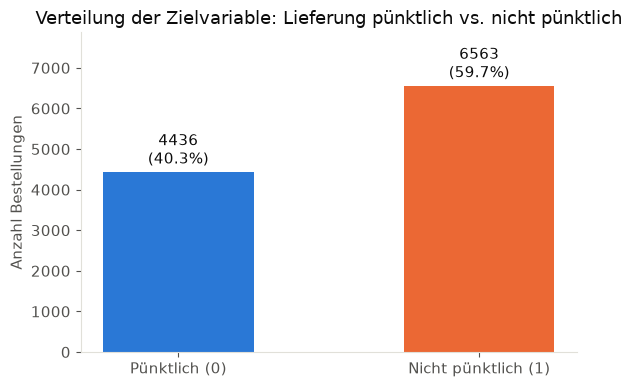

In [12]:
counts = df["Reached.on.Time_Y.N"].value_counts().sort_index()
labels = ["Pünktlich (0)", "Nicht pünktlich (1)"]
colors = [COLOR_BLUE, COLOR_ORANGE]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{count}\n({pct:.1f}%)", ha="center", va="bottom")

ax.set_ylabel("Anzahl Bestellungen")
ax.set_title("Verteilung der Zielvariable: Lieferung pünktlich vs. nicht pünktlich")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

**Interpretation:** 6'563 von 10'999 Bestellungen sind verspätet (59,7 %), 4'436 sind pünktlich (40,3 %). Deshalb muss ein Modell mit der einfachen Baseline verglichen werden, die immer Klasse 1 vorhersagt.

Accuracy zeigt die Gesamtquote richtiger Vorhersagen. Precision zeigt, wie viele gemeldete Verspätungen tatsächlich verspätet sind. Recall zeigt, wie viele tatsächliche Verspätungen erkannt werden.

### Visualisierung 2: Korrelationen numerischer Merkmale

Die Heatmap zeigt lineare Zusammenhänge zwischen numerischen Spalten. Werte nahe 1 bedeuten einen positiven, Werte nahe -1 einen negativen Zusammenhang. Korrelation ist keine Kausalität.

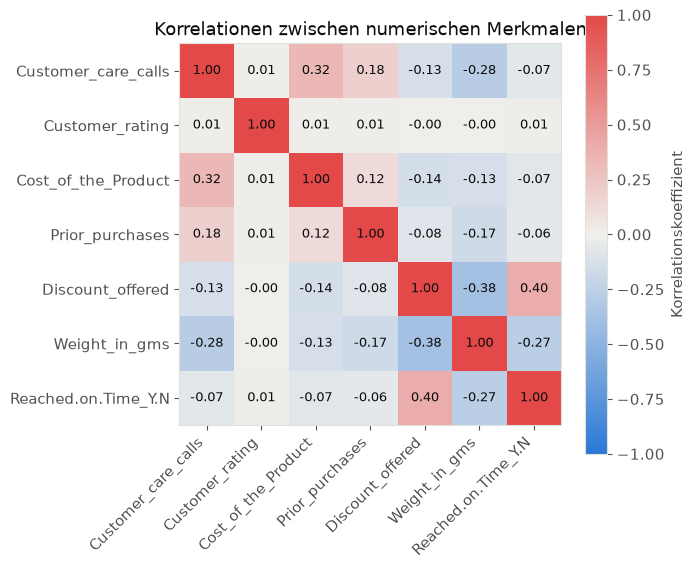

In [13]:
num_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]
corr = df[num_cols].corr()

diverging_cmap = LinearSegmentedColormap.from_list(
    "blue_red", ["#2a78d6", "#f0efec", "#e34948"]
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color=INK_COLOR, fontsize=9)

fig.colorbar(im, ax=ax, label="Korrelationskoeffizient")
ax.set_title("Korrelationen zwischen numerischen Merkmalen")
plt.tight_layout()
plt.show()

**Interpretation:** `Discount_offered` zeigt mit rund 0,40 den stärksten linearen Zusammenhang mit Verspätung. `Weight_in_gms` liegt bei rund -0,27. Die übrigen linearen Zusammenhänge sind schwach.

Diese Werte sind nur eine erste Orientierung. Nichtlineare Muster und Kombinationen können trotzdem für die Modelle relevant sein.

### Visualisierung 3: Rabatt nach Lieferstatus

Der Boxplot vergleicht die Rabattverteilung für pünktliche und verspätete Lieferungen. Der Median liegt bei den verspäteten Lieferungen deutlich höher.

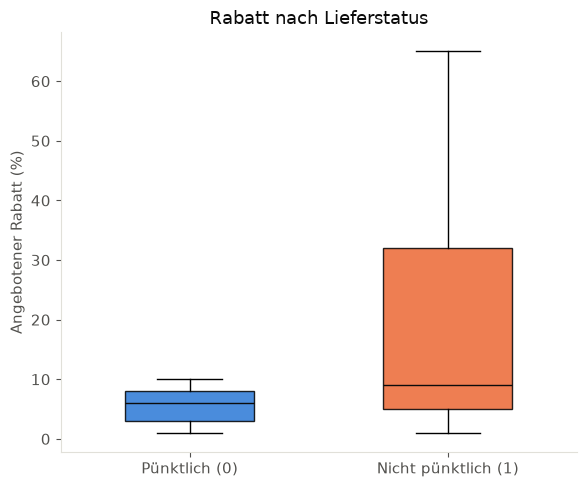

In [14]:
data_by_target = [df.loc[df["Reached.on.Time_Y.N"] == 0, "Discount_offered"],
                  df.loc[df["Reached.on.Time_Y.N"] == 1, "Discount_offered"]]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(data_by_target, tick_labels=["Pünktlich (0)", "Nicht pünktlich (1)"],
                 patch_artist=True, widths=0.5, medianprops=dict(color=INK_COLOR))

for patch, color in zip(bp["boxes"], [COLOR_BLUE, COLOR_ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_ylabel("Angebotener Rabatt (%)")
ax.set_title("Rabatt nach Lieferstatus")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Interpretation:** Hohe Rabatte treten in diesem Datensatz fast nur bei verspäteten Lieferungen auf. Das ist ein starker Zusammenhang, aber kein Beweis dafür, dass der Rabatt die Verspätung verursacht. Eine nicht erfasste Variable kann beide Merkmale beeinflussen.

### Zusammenfassung der EDA

- Verspätete Lieferungen bilden mit 59,7 % die grössere Klasse.
- `Discount_offered` und `Weight_in_gms` zeigen die stärksten linearen Zusammenhänge.
- Korrelationen beschreiben keine Ursachen.
- Die folgende Gruppenanalyse prüft, ob Schwellen oder Intervalle besser passen als ein linearer Zusammenhang.

## 2.4 Feature Engineering

### Kategoriale Variablen kodieren

Kategoriale Merkmale werden mit One-Hot-Encoding über `pd.get_dummies()` in binäre Indikatorspalten umgewandelt. Dadurch entsteht keine künstliche Rangfolge. `drop_first=True` lässt je Merkmal eine Referenzkategorie weg. Die Kodierung wird im bestehenden Ablauf vor dem Train/Test-Split auf die Merkmale angewendet und verwendet die Zielvariable nicht; die daraus entstehende Limitation wird bei der Methodik berücksichtigt.

In [15]:
# One-Hot-Encoding aller kategorialen Spalten
df = pd.get_dummies(
    df,
    columns=["Warehouse_block", "Mode_of_Shipment", "Gender", "Product_importance"],
    drop_first=True,
)

df.head()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_ROAD,Mode_of_Shipment_SHIP,Gender_M,Product_importance_LOW,Product_importance_MEDIUM
0,1,4,2,177,3,44,1233,1,False,False,True,False,False,False,False,True,False
1,2,4,5,216,2,59,3088,1,False,False,False,True,False,False,True,True,False
2,3,2,2,183,4,48,3374,1,False,False,False,False,False,False,True,True,False
3,4,3,3,176,4,10,1177,1,True,False,False,False,False,False,True,False,True
4,5,2,2,184,3,46,2484,1,False,True,False,False,False,False,False,False,True


### Abgeleitetes Feature: `Discount_ratio`

`Discount_ratio` teilt den Rabatt durch den Produktpreis. Die Idee wird als zusätzliche Hypothese geprüft. Die Einheit ist in der Quelle nicht dokumentiert; die relative Variante wird deshalb nur als Hypothese geprüft.

In [16]:
df["Discount_ratio"] = df["Discount_offered"] / df["Cost_of_the_Product"]

print(df[["Discount_offered", "Cost_of_the_Product", "Discount_ratio"]].head())
print()
print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Discount_offered", "Discount_ratio", "Reached.on.Time_Y.N"]].corr()["Reached.on.Time_Y.N"])

   Discount_offered  Cost_of_the_Product  Discount_ratio
0                44                  177        0.248588
1                59                  216        0.273148
2                48                  183        0.262295
3                10                  176        0.056818
4                46                  184        0.250000

Korrelation mit Reached.on.Time_Y.N:
Discount_offered       0.397108
Discount_ratio         0.380484
Reached.on.Time_Y.N    1.000000
Name: Reached.on.Time_Y.N, dtype: float64


**Interpretation:** `Discount_ratio` zeigt eine etwas schwächere Korrelation mit der Zielvariable als `Discount_offered`. Das Feature bleibt als überprüfte Variante erhalten; die Korrelation allein entscheidet nicht über seinen möglichen Nutzen im Random Forest.

### Abgeleitetes Feature: `Price_per_gram`

`Price_per_gram` setzt Produktpreis und Gewicht ins Verhältnis. Damit wird geprüft, ob eine hohe Wertdichte mit verspäteten Lieferungen zusammenhängt.

In [17]:
df["Price_per_gram"] = df["Cost_of_the_Product"] / df["Weight_in_gms"]

print(df[["Cost_of_the_Product", "Weight_in_gms", "Price_per_gram"]].head())
print()
print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Cost_of_the_Product", "Weight_in_gms", "Price_per_gram", "Reached.on.Time_Y.N"]]
      .corr()["Reached.on.Time_Y.N"].round(4))
print()
print("Durchschnittliche Wertdichte nach Lieferstatus:")
print(df.groupby("Reached.on.Time_Y.N")["Price_per_gram"].mean().round(4))

   Cost_of_the_Product  Weight_in_gms  Price_per_gram
0                  177           1233        0.143552
1                  216           3088        0.069948
2                  183           3374        0.054238
3                  176           1177        0.149533
4                  184           2484        0.074074

Korrelation mit Reached.on.Time_Y.N:
Cost_of_the_Product   -0.0736
Weight_in_gms         -0.2688
Price_per_gram         0.0871
Reached.on.Time_Y.N    1.0000
Name: Reached.on.Time_Y.N, dtype: float64

Durchschnittliche Wertdichte nach Lieferstatus:
Reached.on.Time_Y.N
0    0.0733
1    0.0832
Name: Price_per_gram, dtype: float64


**Interpretation:** `Price_per_gram` zeigt nur einen schwachen Zusammenhang. Das Feature wird nicht als zentrale Erklärung verwendet, bleibt aber für den Modellvergleich erhalten.

### Abgeleitete Features: `High_discount` und `Weight_critical`

Die Gruppenanalyse über den vollständigen Datensatz zeigt eine Rabatt-Schwelle und ein kritisches Gewichtsintervall. `High_discount` markiert Werte über 10, `Weight_critical` das Intervall von 2'000 bis 4'000 g. Die Merkmale werden im bestehenden Ablauf vor dem Train/Test-Split erzeugt. Dadurch kann die zielbezogene Schwellenwahl Informationen aus dem späteren Testset nutzen; das ist eine methodische Limitation der Evaluation.

In [18]:
# Verspätungsrate je Rabatt-Stufe und je Gewichts-Stufe
rabatt_stufen = pd.cut(df["Discount_offered"], [0, 5, 10, 15, 20, 30, 70], include_lowest=True)
gewicht_stufen = pd.cut(df["Weight_in_gms"], [0, 1000, 2000, 3000, 4000, 5000, 6000, 8000])

print("Verspätungsrate nach Rabatt-Stufe:")
print(df.groupby(rabatt_stufen, observed=True)["Reached.on.Time_Y.N"]
        .agg(anzahl="size", anteil_verspaetet="mean").round(3))
print()
print("Verspätungsrate nach Gewichts-Stufe:")
print(df.groupby(gewicht_stufen, observed=True)["Reached.on.Time_Y.N"]
        .agg(anzahl="size", anteil_verspaetet="mean").round(3))

Verspätungsrate nach Rabatt-Stufe:
                  anzahl  anteil_verspaetet
Discount_offered                           
(-0.001, 5.0]       4157              0.474
(5.0, 10.0]         4195              0.464
(10.0, 15.0]         252              1.000
(15.0, 20.0]         244              1.000
(20.0, 30.0]         441              1.000
(30.0, 70.0]        1710              1.000

Verspätungsrate nach Gewichts-Stufe:
               anzahl  anteil_verspaetet
Weight_in_gms                           
(1000, 2000]     3245              0.678
(2000, 3000]      899              1.000
(3000, 4000]      889              0.999
(4000, 5000]     3077              0.437
(5000, 6000]     2881              0.425
(6000, 8000]        8              1.000


**Befund:** Von 2'647 Bestellungen mit einem Rabatt über 10 kamen 2'647 verspätet an. Im Bereich von 2'000 bis 4'000 g liegt die Verspätungsrate in den beiden Gruppen bei 1,000 beziehungsweise 0,999. Diese starken Muster begründen die beiden binären Merkmale, sind aber keine Kausalitätsnachweise.

In [19]:
df["High_discount"] = (df["Discount_offered"] > 10).astype(int)
df["Weight_critical"] = df["Weight_in_gms"].between(2000, 4000).astype(int)

print("Korrelation mit Reached.on.Time_Y.N:")
print(df[["Discount_offered", "High_discount", "Weight_in_gms", "Weight_critical",
          "Reached.on.Time_Y.N"]].corr()["Reached.on.Time_Y.N"].round(4))

Korrelation mit Reached.on.Time_Y.N:
Discount_offered       0.3971
High_discount          0.4628
Weight_in_gms         -0.2688
Weight_critical        0.3612
Reached.on.Time_Y.N    1.0000
Name: Reached.on.Time_Y.N, dtype: float64


**Interpretation:** `High_discount` und `Weight_critical` bilden die im vollständigen Datensatz beobachteten Muster direkter ab als die Rohwerte. Die Regelprüfung ist eine explorative Orientierung und keine Modellbewertung. Weil die Schwellen vor dem Split festgelegt wurden, müssen die Testmetriken mit dieser Einschränkung gelesen werden.

## 2.5 Train/Test-Split

Der Split verwendet 80 % Trainingsdaten und 20 % Testdaten. Das ergibt 8'799 Trainings- und 2'200 Testbestellungen. `stratify=y` hält den Klassenanteil von rund 59,7 % verspäteten und 40,3 % pünktlichen Lieferungen in beiden Teilmengen möglichst gleich. Die vor dem Split abgeleiteten Schwellenmerkmale bleiben dabei die genannte Leakage-Limitation.

Der technische Split wird einmalig mit `stratify=y` und `random_state=42` ausgeführt. Dadurch ist die Aufteilung reproduzierbar und das Testset kann für den abschliessenden Modellvergleich zurückgehalten werden. Die bereits vorher erzeugten Schwellenmerkmale werden in dieser Arbeit nicht nachträglich neu bestimmt.

In [20]:
X = df.drop(columns=["ID", "Reached.on.Time_Y.N"])
y = df["Reached.on.Time_Y.N"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trainingsdaten: {X_train.shape[0]} Samples, Testdaten: {X_test.shape[0]} Samples")
print(f"Verwendete Merkmale: {X.shape[1]}")
print()
print("Klassenverteilung gesamt:")
print(y.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Training:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Klassenverteilung Test:")
print(y_test.value_counts(normalize=True).round(3))

Trainingsdaten: 8799 Samples, Testdaten: 2200 Samples
Verwendete Merkmale: 19

Klassenverteilung gesamt:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Training:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64

Klassenverteilung Test:
Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64


# Teil 3 - Modellwahl und Training

## 3.1 Modellwahl

Wir vergleichen **Logistic Regression** und **Random Forest**.

### Modell 1: Logistic Regression

Die Logistic Regression gewichtet jedes Merkmal und kombiniert diese Beiträge zu einer Wahrscheinlichkeit für Klasse 1. Dadurch bleibt nachvollziehbar, welche Merkmale die Vorhersage in welche Richtung beeinflussen. Wir wählen sie als einfaches und gut interpretierbares Vergleichsmodell.

### Modell 2: Random Forest

Der Random Forest kombiniert viele Entscheidungsbäume, die jeweils Regeln für Teilmengen der Daten lernen und gemeinsam abstimmen. Dadurch kann er nichtlineare Schwellen und Wechselwirkungen zwischen Merkmalen erfassen, ist aber schwieriger direkt zu erklären. Wir wählen ihn als flexiblen Vergleich zum linearen Modell.

Beide Modelle passen zum binären Ziel. Der Vergleich zeigt, ob die zusätzliche Modellkomplexität einen messbaren Vorteil bringt.

Die Testdaten werden nicht direkt zum Fitten der Modelle verwendet. Die vorbereiteten Merkmale wurden jedoch vor dem Split aus dem vollständigen Datensatz erzeugt. Diese Einschränkung wird bei der Interpretation und bei den Verbesserungsmöglichkeiten berücksichtigt.

### Modell 1: Logistic Regression

Die kategorialen Merkmale liegen nach `pd.get_dummies()` numerisch vor. `StandardScaler` bringt Merkmale mit sehr unterschiedlichen Grössenordnungen auf eine vergleichbare Skala, was die Optimierung der Logistic Regression unterstützt. Die Pipeline verbindet Skalierung und Modelltraining; ihre Skalierungsparameter werden nur aus den Trainingsdaten gelernt. Die One-Hot-Kodierung selbst erfolgt im bestehenden Ablauf bereits vor dem Split.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)

cv_log_reg = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy")
print(f"Logistic Regression - CV-Accuracy: {cv_log_reg.mean():.4f} (+/- {cv_log_reg.std():.4f})")
print(f"Logistic Regression - Train-Accuracy: {log_reg.score(X_train, y_train):.4f}")

Logistic Regression - CV-Accuracy: 0.6742 (+/- 0.0110)
Logistic Regression - Train-Accuracy: 0.6820


**Anpassungen und Tuning:**

- `StandardScaler` und `max_iter=1000` ermöglichen eine stabile Optimierung.
- `random_state=42` macht den Lauf reproduzierbar.
- `C` steuert die Stärke der Regularisierung: kleine Werte begrenzen die Modellkomplexität.
- `class_weight` kann die kleinere pünktliche Klasse stärker gewichten.
- `GridSearchCV` prüft beide Parameter mit fünffacher Cross-Validation auf den Trainingsdaten.

Die Suche umfasst 8 Parameterkombinationen plus Faltungen und Refits. Als Auswahlkriterium wird Accuracy verwendet; Recall und F1-Score werden anschliessend separat bewertet. Das ist eine bewusste, aber für das Frühwarnziel nicht optimale Auswahl.

In [22]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring="accuracy", n_jobs=-1)
grid_lr.fit(X_train, y_train)

log_reg_best = grid_lr.best_estimator_

print(f"Beste Parameter: {grid_lr.best_params_}")
print(f"Beste CV-Accuracy: {grid_lr.best_score_:.4f}")

Beste Parameter: {'clf__C': 0.01, 'clf__class_weight': 'balanced'}
Beste CV-Accuracy: 0.6787


### Modell 2: Random Forest

Ein Random Forest benötigt keine Skalierung, weil Entscheidungsbäume Schwellen vergleichen. Viele Bäume lernen unterschiedliche Teilregeln und stimmen anschliessend über die Klasse ab. Die kategorialen Merkmale wurden zuvor durch `pd.get_dummies()` numerisch kodiert. Zuerst dient die Standardeinstellung als Referenz; danach werden Baumtiefe, Blattgrösse und Anzahl Bäume per Grid Search geprüft.

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

cv_rf_default = cross_val_score(rf_default, X_train, y_train, cv=5, scoring="accuracy")
print(f"Random Forest (Default) - CV-Accuracy: {cv_rf_default.mean():.4f} (+/- {cv_rf_default.std():.4f})")
print(f"Random Forest (Default) - Train-Accuracy: {rf_default.score(X_train, y_train):.4f}")

Random Forest (Default) - CV-Accuracy: 0.6606 (+/- 0.0096)
Random Forest (Default) - Train-Accuracy: 1.0000


**Beobachtung:** Das Standardmodell erreicht auf den Trainingsdaten 100 % Accuracy, aber nur rund 66,1 % CV-Accuracy. Diese grosse Differenz zeigt Overfitting: Das Modell merkt sich Trainingsfälle besser, als es auf unbekannte Daten generalisiert. Die Suche nach begrenzter Baumtiefe und passenden Blattgrössen soll diese Überanpassung reduzieren.

In [24]:
param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [5, 10, None],
    "min_samples_leaf": [1, 5, 20],
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf,
                       cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_

print(f"Beste Parameter: {grid_rf.best_params_}")
print(f"Beste CV-Accuracy: {grid_rf.best_score_:.4f}")
print(f"Train-Accuracy des besten Modells: {rf_best.score(X_train, y_train):.4f}")
print()
print("Top 5 Parameterkombinationen:")
ergebnisse = pd.DataFrame(grid_rf.cv_results_)[
    ["param_max_depth", "param_min_samples_leaf", "param_n_estimators", "mean_test_score"]
]
print(ergebnisse.sort_values("mean_test_score", ascending=False).head().to_string(index=False))

Beste Parameter: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Beste CV-Accuracy: 0.6877
Train-Accuracy des besten Modells: 0.6926

Top 5 Parameterkombinationen:
param_max_depth  param_min_samples_leaf  param_n_estimators  mean_test_score
              5                       1                 300         0.687693
              5                       5                 300         0.686897
              5                      20                 300         0.686783
              5                      20                 100         0.686329
              5                       5                 100         0.686102


**Ergebnis des Tunings:** Die Codeausgabe zeigt die besten Parameter und die führenden Kombinationen. Die beste CV-Accuracy beträgt 0,6787 für die Logistic Regression und 0,6877 für den Random Forest. Der Random Forest liegt damit im Training-Vergleich knapp vorne; das Testset wird erst danach bewertet. Die bestehenden Schwellenmerkmale wurden dabei nicht nachträglich verändert.

## 3.3 Vorhersage

Beide getunten Modelle erzeugen Vorhersagen und Wahrscheinlichkeiten für die 2'200 Testbestellungen. Es erfolgt danach keine weitere Anpassung.

In [25]:
# Vorhersagen beider Modelle auf den Testdaten
y_pred_log_reg = log_reg_best.predict(X_test)
y_pred_rf = rf_best.predict(X_test)

# Wahrscheinlichkeit fuer die Klasse 1 ("kommt zu spaet")
proba_log_reg = log_reg_best.predict_proba(X_test)[:, 1]
proba_rf = rf_best.predict_proba(X_test)[:, 1]

print(f"Vorhersagen erstellt fuer {len(y_pred_rf)} Testbestellungen.")

Vorhersagen erstellt fuer 2200 Testbestellungen.


Die ersten 15 Zeilen zeigen die tatsächliche Klasse, die Vorhersage beider Modelle und die jeweilige Wahrscheinlichkeit.

In [26]:
vorhersagen = pd.DataFrame({
    "Tatsächlich": y_test.values,
    "LogReg": y_pred_log_reg,
    "LogReg_Wahrsch.": proba_log_reg.round(2),
    "RandomForest": y_pred_rf,
    "RF_Wahrsch.": proba_rf.round(2),
}, index=y_test.index)

vorhersagen["LogReg_ok"] = ["richtig" if a == b else "FALSCH"
                            for a, b in zip(vorhersagen["Tatsächlich"], vorhersagen["LogReg"])]
vorhersagen["RF_ok"] = ["richtig" if a == b else "FALSCH"
                        for a, b in zip(vorhersagen["Tatsächlich"], vorhersagen["RandomForest"])]

print("0 = puenktlich | 1 = kommt zu spaet")
print()
print(vorhersagen.head(15).to_string())

0 = puenktlich | 1 = kommt zu spaet

      Tatsächlich  LogReg  LogReg_Wahrsch.  RandomForest  RF_Wahrsch. LogReg_ok    RF_ok
1666            1       1             1.00             1         1.00   richtig  richtig
6542            1       0             0.36             0         0.47    FALSCH   FALSCH
6428            0       0             0.32             0         0.44   richtig  richtig
8060            0       0             0.34             0         0.43   richtig  richtig
9822            0       0             0.33             0         0.43   richtig  richtig
4478            1       0             0.38             0         0.42    FALSCH   FALSCH
7037            0       0             0.45             0         0.43   richtig  richtig
6264            1       0             0.37             0         0.47    FALSCH   FALSCH
6461            0       0             0.29             0         0.44   richtig  richtig
2546            1       1             0.99             1         1.00   r

## Gesamtübersicht der Vorhersagen

In [27]:
gesamt = len(y_test)

print("Wie oft wurde welche Klasse vorhergesagt?")
print(f"{'':22s}{'pünktlich (0)':>15s}{'zu spät (1)':>15s}")
for name, pred in [("Tatsächlich", y_test.values),
                   ("Logistic Regression", y_pred_log_reg),
                   ("Random Forest", y_pred_rf)]:
    anzahl_0 = (pred == 0).sum()
    anzahl_1 = (pred == 1).sum()
    print(f"{name:22s}{anzahl_0:>7d} ({anzahl_0/gesamt:>4.0%}){anzahl_1:>8d} ({anzahl_1/gesamt:>4.0%})")

print()
print("Wie viele Vorhersagen waren richtig?")
for name, pred in [("Logistic Regression", y_pred_log_reg), ("Random Forest", y_pred_rf)]:
    treffer = (pred == y_test.values).sum()
    print(f"  {name:22s}{treffer:>6d} von {gesamt}  ({treffer/gesamt:.2%})")

print()
einig = (y_pred_log_reg == y_pred_rf).sum()
print(f"Beide Modelle einig:      {einig:>6d} von {gesamt}  ({einig/gesamt:.2%})")
print(f"Modelle uneinig:          {gesamt-einig:>6d} von {gesamt}  ({(gesamt-einig)/gesamt:.2%})")

Wie oft wurde welche Klasse vorhergesagt?
                        pünktlich (0)    zu spät (1)
Tatsächlich               887 ( 40%)    1313 ( 60%)
Logistic Regression      1604 ( 73%)     596 ( 27%)
Random Forest            1546 ( 70%)     654 ( 30%)

Wie viele Vorhersagen waren richtig?
  Logistic Regression     1479 von 2200  (67.23%)
  Random Forest           1491 von 2200  (67.77%)

Beide Modelle einig:        2140 von 2200  (97.27%)
Modelle uneinig:              60 von 2200  (2.73%)


**Wahrscheinlichkeitsgruppen:** Die Testbestellungen werden nach der vom Random Forest ausgegebenen Wahrscheinlichkeit gruppiert. Verglichen werden Trefferquote und tatsächlicher Anteil verspäteter Lieferungen.

In [28]:
stufen = pd.cut(proba_rf, [0, 0.45, 0.55, 0.7, 0.9, 1.0], include_lowest=True,
                labels=["unter 45 % (eher pünktlich)", "45-55 % (Münzwurf)",
                        "55-70 % (leichte Tendenz)", "70-90 % (ziemlich sicher)",
                        "über 90 % (so gut wie sicher)"])

auswertung = pd.DataFrame({
    "stufe": stufen,
    "richtig": y_pred_rf == y_test.values,
    "tatsaechlich_spaet": y_test.values,
})

print("Random Forest - Sicherheit der Vorhersage vs. tatsächliches Ergebnis:")
print(auswertung.groupby("stufe", observed=False).agg(
    anzahl=("richtig", "size"),
    anteil_richtig=("richtig", "mean"),
    anteil_tatsaechlich_spaet=("tatsaechlich_spaet", "mean"),
).round(3).to_string())

print()
print(f"Niedrigste vergebene Wahrscheinlichkeit: {proba_rf.min():.2f}")
print(f"Höchste vergebene Wahrscheinlichkeit:    {proba_rf.max():.2f}")

Random Forest - Sicherheit der Vorhersage vs. tatsächliches Ergebnis:
                               anzahl  anteil_richtig  anteil_tatsaechlich_spaet
stufe                                                                           
unter 45 % (eher pünktlich)       935           0.579                      0.421
45-55 % (Münzwurf)                636           0.524                      0.475
55-70 % (leichte Tendenz)          50           0.760                      0.760
70-90 % (ziemlich sicher)          46           1.000                      1.000
über 90 % (so gut wie sicher)     533           1.000                      1.000

Niedrigste vergebene Wahrscheinlichkeit: 0.40
Höchste vergebene Wahrscheinlichkeit:    1.00


**Interpretation:** Beide Modelle sagen deutlich weniger Verspätungen voraus, als tatsächlich vorkommen. Sie stimmen in den meisten Fällen überein.

Die Wahrscheinlichkeitsgruppen zeigen zudem eine klare Trennung zwischen sicheren und unsicheren Fällen. Dieser Befund ist für eine gezielte Priorisierung nützlich, ersetzt aber keine Prüfung auf einem unabhängigen Datensatz.

# Teil 4 - Auswertung, Fazit und Verbesserungsmöglichkeiten

Für die binäre Klassifikation werden Accuracy, Precision, Recall, F1-Score und Confusion Matrix berechnet.

Recall ist für diesen Use Case besonders relevant, weil eine übersehene Verspätung problematischer ist als ein zusätzlicher Warnhinweis. Das Tuning verwendet jedoch Accuracy. Die Vorhersagen nutzen weiterhin die Standard-Schwelle von 0,5; die Wahrscheinlichkeitsgruppen beschreiben die Testfälle nur nachträglich und optimieren keine Schwelle. Eine Precision-Recall-Analyse mit kostenbezogener Schwellenwahl bleibt deshalb eine Verbesserung.

In [29]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def kennzahlen(y_wahr, y_vorhersage):
    return {
        "Accuracy": accuracy_score(y_wahr, y_vorhersage),
        "Precision": precision_score(y_wahr, y_vorhersage),
        "Recall": recall_score(y_wahr, y_vorhersage),
        "F1-Score": f1_score(y_wahr, y_vorhersage),
    }

# Baseline: immer "kommt zu spaet" vorhersagen
baseline = pd.Series(1, index=y_test.index)

vergleich = pd.DataFrame({
    "Logistic Regression": kennzahlen(y_test, y_pred_log_reg),
    "Random Forest": kennzahlen(y_test, y_pred_rf),
    "Baseline (immer 'zu spät')": kennzahlen(y_test, baseline),
}).round(4)

print("Vergleich der Modelle auf den Testdaten (2.200 Bestellungen)")
print("Bezugsklasse: 1 = 'kommt zu spät'")
print()
print(vergleich.to_string())

Vergleich der Modelle auf den Testdaten (2.200 Bestellungen)
Bezugsklasse: 1 = 'kommt zu spät'

           Logistic Regression  Random Forest  Baseline (immer 'zu spät')
Accuracy                0.6723         0.6777                      0.5968
Precision               0.9966         0.9618                      0.5968
Recall                  0.4524         0.4791                      1.0000
F1-Score                0.6223         0.6396                      0.7475


### Confusion Matrix

Die Confusion Matrix unterscheidet richtige Vorhersagen, falsche Alarme und übersehene Verspätungen. Die Achsenbeschriftungen zeigen tatsächliche und vorhergesagte Klasse.

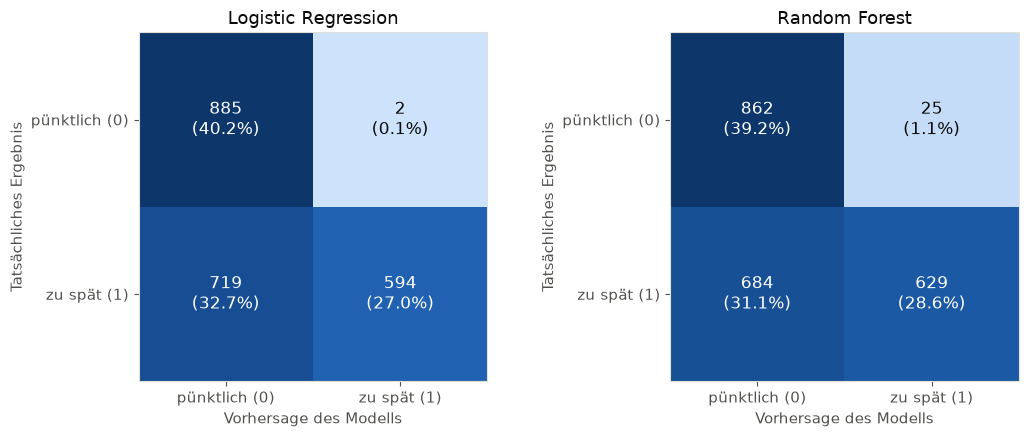

Detaillierter Bericht - Random Forest:
               precision    recall  f1-score   support

pünktlich (0)      0.558     0.972     0.709       887
  zu spät (1)      0.962     0.479     0.640      1313

     accuracy                          0.678      2200
    macro avg      0.760     0.725     0.674      2200
 weighted avg      0.799     0.678     0.667      2200



In [30]:
from matplotlib.colors import LinearSegmentedColormap

blau_ramp = LinearSegmentedColormap.from_list("blau", ["#cde2fb", "#2a78d6", "#0d366b"])
beschriftung = ["pünktlich (0)", "zu spät (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (titel, vorhersage) in zip(axes, [("Logistic Regression", y_pred_log_reg),
                                          ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, vorhersage)
    ax.imshow(cm, cmap=blau_ramp, vmin=0, vmax=cm.max())

    for zeile in range(2):
        for spalte in range(2):
            wert = cm[zeile, spalte]
            ax.text(spalte, zeile, f"{wert}\n({wert/cm.sum():.1%})", ha="center", va="center",
                    fontsize=12, color="#ffffff" if wert > cm.max() * 0.5 else INK_COLOR)

    ax.set_xticks([0, 1], beschriftung)
    ax.set_yticks([0, 1], beschriftung)
    ax.set_xlabel("Vorhersage des Modells")
    ax.set_ylabel("Tatsächliches Ergebnis")
    ax.set_title(titel)

plt.tight_layout()
plt.show()

print("Detaillierter Bericht - Random Forest:")
print(classification_report(y_test, y_pred_rf,
                            target_names=["pünktlich (0)", "zu spät (1)"], digits=3))

### Was sagen die Metriken aus?

Auf dem Testset erreicht die Logistic Regression Accuracy 0,6723, Precision 0,9966, Recall 0,4524 und F1-Score 0,6223. Der Random Forest erreicht 0,6777, 0,9618, 0,4791 und 0,6396. Der Random Forest ist damit nur knapp besser und übersieht weiterhin mehr als die Hälfte der tatsächlichen Verspätungen.

Accuracy misst die Gesamtquote, Precision die Zuverlässigkeit eines Alarms, Recall die Erkennung tatsächlicher Verspätungen und F1-Score das Zusammenspiel von Precision und Recall.

### Einordnung der Baseline

Die Baseline «immer zu spät» erreicht Recall 1,0000 und F1-Score 0,7475, produziert aber für jede Bestellung eine Warnung. Sie hat deshalb keine Trennschärfe und ist für eine gezielte Entscheidung unbrauchbar. Sie bleibt trotzdem ein wichtiger Referenzpunkt.

### Praxiseignung

Für ein vollständiges Frühwarnsystem reicht das Ergebnis nicht. Als Filter für besonders sichere Fälle kann das Modell eingeschränkt nützlich sein; für einen produktiven Einsatz wären bessere Daten und eine geschäftlich begründete Schwelle nötig.

### Welches Modell schneidet besser ab?

Der Random Forest liegt in der Testauswertung knapp vor der Logistic Regression. Die Logistic Regression ist leichter zu erklären und erreicht eine höhere Precision. Die endgültige Wahl hängt deshalb von den Kosten falscher Alarme und übersehener Verspätungen ab.

### Welche Features sind am wichtigsten?

Die Grafik zeigt die modellinterne Feature Importance des Random Forest. Diese Werte beschreiben die Nutzung im Modell, nicht den kausalen Einfluss auf Verspätungen. Die Koeffizienten der Logistic Regression ergänzen die Richtung der linearen Modellbeiträge.

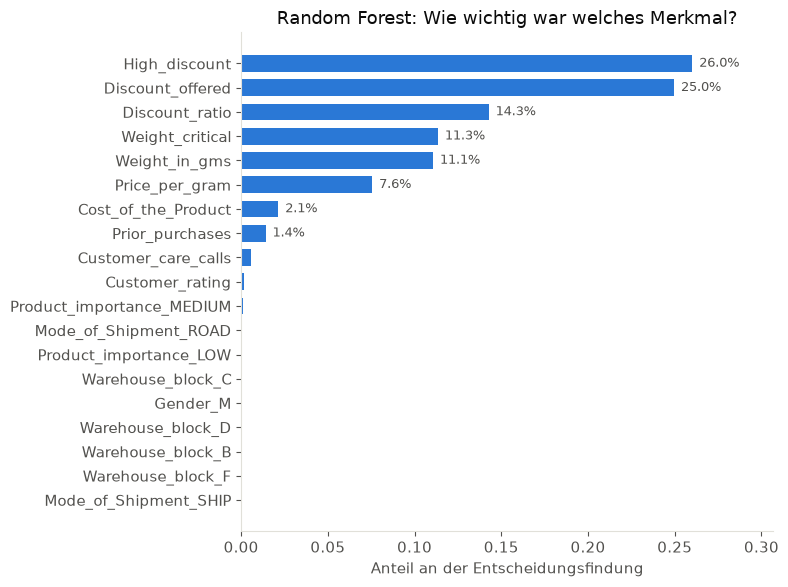

Gewichte der Logistic Regression (Vorzeichen = Richtung des Einflusses):
High_discount       0.894
Weight_critical     0.812
Weight_in_gms      -0.356
Discount_ratio      0.317
Discount_offered    0.262
Price_per_gram     -0.150


In [31]:
wichtigkeit = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
balken = ax.barh(wichtigkeit.index, wichtigkeit.values, color=COLOR_BLUE, height=0.7)

for balken_einzeln, wert in zip(balken, wichtigkeit.values):
    if wert > 0.01:
        ax.text(wert + 0.004, balken_einzeln.get_y() + balken_einzeln.get_height() / 2,
                f"{wert:.1%}", va="center", fontsize=9, color=TEXT_COLOR)

ax.set_xlabel("Anteil an der Entscheidungsfindung")
ax.set_title("Random Forest: Wie wichtig war welches Merkmal?")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, wichtigkeit.max() * 1.18)
plt.tight_layout()
plt.show()

print("Gewichte der Logistic Regression (Vorzeichen = Richtung des Einflusses):")
koeffizienten = pd.Series(log_reg_best.named_steps["clf"].coef_[0], index=X_train.columns)
print(koeffizienten.reindex(koeffizienten.abs().sort_values(ascending=False).index).head(6).round(3).to_string())

**Interpretation:** Rabatt- und Gewichtsmerkmale dominieren die modellinterne Importance. Das bestätigt die EDA als Vorhersagebefund, beweist aber keine Ursache. Die Werte sind ausserdem abhängig vom verwendeten Modell und Datensatz.

## 4.3 Fazit

### Antwort auf die Business-Fragestellung

Das Modell kann einen Teil der verspäteten Lieferungen erkennen, aber kein zuverlässiges Frühwarnsystem für alle Bestellungen bereitstellen. Besonders klare Muster betreffen hohe Rabatte und ein mittleres Gewichtsintervall.

### Wurde das Ziel erreicht?

**Methodisch ja, praktisch nur eingeschränkt.** Datenqualität, EDA, Feature Engineering, Training und Evaluation wurden durchgeführt. Im Test liegt der Random Forest bei 0,6777 Accuracy und 0,4791 Recall; er erkennt damit weniger als die Hälfte der tatsächlichen Verspätungen. Die Testmetriken zeigen ausserdem, dass wichtige Einflussgrössen wie Entfernung, Wetter, Zoll, Saison und Logistikauslastung fehlen.

Die auffällige Rabattregel wurde vor dem Split aus dem vollständigen Datensatz abgeleitet und begrenzt deshalb die Aussagekraft der Testmetriken. Die Regel und der schwache Zusammenhang der Versandart sollten vor einer geschäftlichen Nutzung mit echten Betriebsdaten geprüft werden. Die Ergebnisse dieses Datensatzes sind kein Kausalitätsnachweis.

## 4.4 Verbesserungsmöglichkeiten

1. **Bessere Daten:** Bestelldatum, Entfernung, Zielland, Dienstleister, Auslastung, Wetter und Feiertage erfassen.
2. **Entscheidungsschwelle prüfen:** Mit einer Precision-Recall-Kurve einen passenden Kompromiss zwischen Warnungen und übersehenen Verspätungen bestimmen.
3. **Leakage-freie Feature-Auswahl:** Schwellen und andere zielbezogene Merkmale erst nach dem Split aus den Trainingsdaten ableiten.
4. **Weitere Modelle vergleichen:** Gradient Boosting und andere Klassifikationsverfahren mit derselben Evaluation prüfen.
5. **Datenquelle validieren:** Auffällige Muster mit realen Betriebsdaten überprüfen.

## Quellen und KI-Nutzung

Datensatzquelle: [Kaggle Customer Analytics](https://www.kaggle.com/datasets/prachi13/customer-analytics).

KI wurde zur Strukturierung und sprachlichen Überarbeitung genutzt. Code, Ausgaben und fachliche Entscheidungen wurden im Notebook ausgeführt und geprüft.